In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             classification_report, confusion_matrix,
                             roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load Data
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv')

model = joblib.load('../data/best_model.pkl')

print(f"Test set: {X_test.shape}")

Test set: (1409, 30)


In [3]:
#Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassifaction Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8027
AUC: 0.8517

Classifaction Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



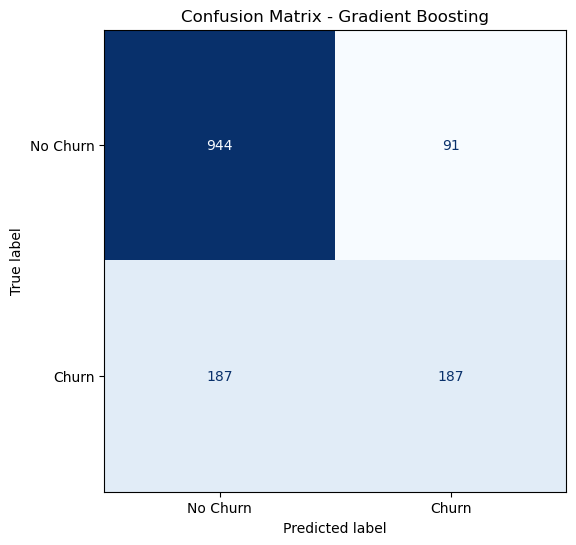

True Negatives (correct No Churn): 944
False Positives (wrong Churn): 91
False Negatives (missed Churn): 187
True Positives (correct Churn): 187


In [6]:
#Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()

#Interpretation
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correct No Churn): {tn}")
print(f"False Positives (wrong Churn): {fp}")
print(f"False Negatives (missed Churn): {fn}")
print(f"True Positives (correct Churn): {tp}")

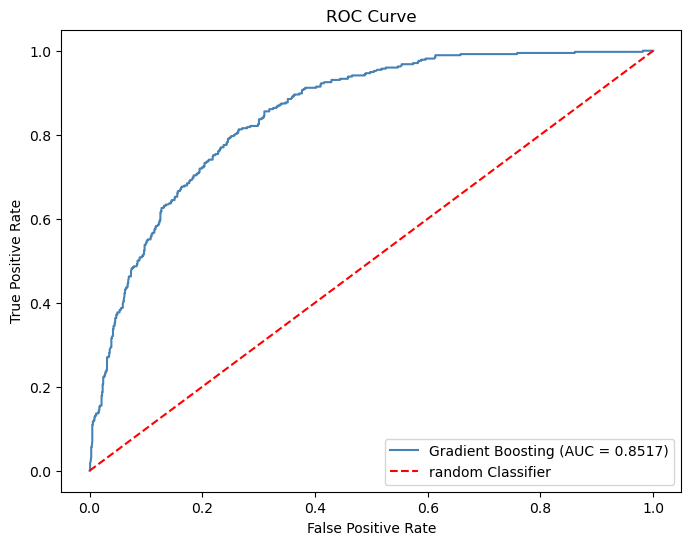

In [8]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='steelblue', label=f'Gradient Boosting (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [9]:
print("=== Evaluation Summary ===")
print(f"\nModel: Gradient Boosting")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_prob):.4f}")
print(f"\nChurn Detection:")
print(f"Correctly identified churners:  {tp} / {tp+fn}")
print(f"Missed churners:                {fn} / {tp+fn}")
print(f"Churn Recall:                   {tp/(tp+fn):.2%}")

=== Evaluation Summary ===

Model: Gradient Boosting
Accuracy:  0.8027
AUC:       0.8517

Churn Detection:
Correctly identified churners:  187 / 374
Missed churners:                187 / 374
Churn Recall:                   50.00%
